In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import category_encoders as ce
import joblib

# Models & Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

1. Loading Data 


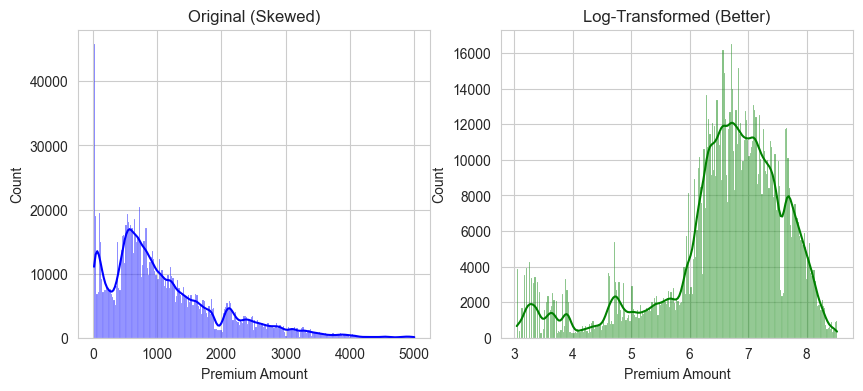

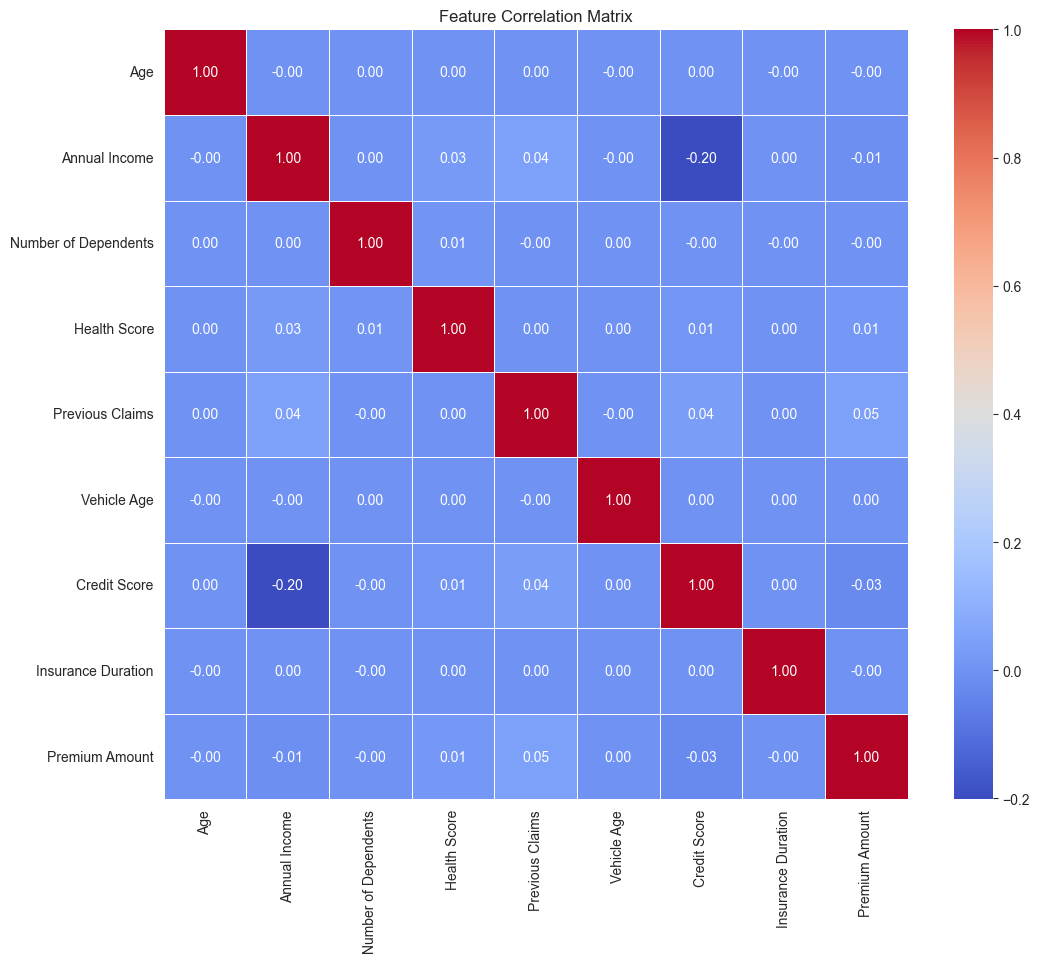

Processing Data
Train Shape: (960000, 22)
Validation Shape: (240000, 22)


In [10]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("1. Loading Data ")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# 2. EDA
# use Log Transform bc Insurance Premiums are skewed
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(train_df['Premium Amount'], kde=True, color='blue')
plt.title('Original (Skewed)')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train_df['Premium Amount']), kde=True, color='green')
plt.title('Log-Transformed (Better)')
plt.show()

# Correlation Heatmap 
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation
numeric_eda = train_df.select_dtypes(include=[np.number]).drop(['id'], axis=1, errors='ignore')
sns.heatmap(numeric_eda.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# 3. Feature Engineering Function 
def process_data(df):
    df = df.copy()
    
    # Requirement: "Temporal feature engineering from policy dates"
    date_cols = [c for c in df.columns if 'Date' in c or 'Start' in c]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df['Policy_Year'] = df[col].dt.year
        df['Policy_Month'] = df[col].dt.month
        
        # Requirement: "Cyclical encoding for time-based features"
        df['Month_sin'] = np.sin(2 * np.pi * df['Policy_Month'] / 12)
        df['Month_cos'] = np.cos(2 * np.pi * df['Policy_Month'] / 12)
        
        df = df.drop(columns=[col])
    return df

print("Processing Data")

X = process_data(train_df.drop(columns=['id', 'Premium Amount']))
y = np.log1p(train_df['Premium Amount']) # Log Target

X_test_submission = process_data(test_df.drop(columns=['id']))

# Split Data (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")

In [11]:
# 1. Column Groups
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Requirement: "Binary encoding for gender and smoking status"
# Separate columns with 2 values (Binary) vs many values (Multi)
binary_candidates = ['Gender', 'Smoking Status', 'Vehicle Damage', 'Smoker'] 
binary_cols = [c for c in cat_cols if c in binary_candidates or X_train[c].nunique() == 2]
multi_cols = [c for c in cat_cols if c not in binary_cols]

print(f"Binary Cols: {binary_cols}")
print(f"Multi Cols: {multi_cols}")

# 2. Build Pipeline Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# Binary
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('binary', ce.BinaryEncoder()) 
])

# Multi-Category
multi_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('target', ce.TargetEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('bin', binary_transformer, binary_cols),
        ('multi', multi_transformer, multi_cols)
    ])

# 3. Best Model
print("Finding Best Model...")

models = {
    'Ridge': Ridge(),
    'XGBoost': XGBRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=200, n_jobs=-1, random_state=42, verbose=-1)
}

best_rmse = float('inf')
best_name = ""
best_pipeline = None

for name, model in models.items():
    pipeline = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    
    preds = pipeline.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    print(f"{name} RMSE (Log Scale): {rmse:.4f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_name = name
        best_pipeline = pipeline

print(f"\nBest Model: {best_name}")

Binary Cols: ['Gender', 'Smoking Status']
Multi Cols: ['Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Customer Feedback', 'Exercise Frequency', 'Property Type']
Finding Best Model...
Ridge RMSE (Log Scale): 1.0890
XGBoost RMSE (Log Scale): 1.0533
LightGBM RMSE (Log Scale): 1.0496

Best Model: LightGBM


In [12]:
# 4. Hyperparameter Tuning
print(f"Tuning {best_name} with GridSearchCV")

if best_name == 'XGBoost':
    param_grid = {
        'model__n_estimators': [100, 200],      
        'model__learning_rate': [0.05, 0.1],    
        'model__max_depth': [3, 5]              
    }
elif best_name == 'LightGBM':
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__num_leaves': [31]            
    }
else:
    # Ridge is already instant
    param_grid = {'model__alpha': [0.1, 1.0, 10.0]}

grid = GridSearchCV(
    best_pipeline, 
    param_grid, 
    cv=3, 
    scoring='neg_root_mean_squared_error', 
    verbose=1, 
    n_jobs=-1  
)

grid.fit(X_train, y_train)

final_model = grid.best_estimator_
print(f"Best Parameters: {grid.best_params_}")

# Final Evaluation
val_preds = final_model.predict(X_val)
# Convert back to real money for the report
val_rmse_actual = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_preds)))
print(f"Final Validation RMSE (Real Currency): ${val_rmse_actual:.2f}")

joblib.dump(final_model, 'insurance_model.pkl')
print("Model saved successfully.")



Tuning LightGBM with GridSearchCV
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters: {'model__learning_rate': 0.05, 'model__n_estimators': 200, 'model__num_leaves': 31}
Final Validation RMSE (Real Currency): $923.97
Model saved successfully.


In [13]:
print("\n Generating Kaggle Submission ")

# 1. Predict on Test Data 
log_preds = final_model.predict(X_test_submission)

# 2. Inverse Transform (Log -> Real Money)
actual_preds = np.expm1(log_preds)

# 3. Create DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'Premium Amount': actual_preds
})

submission.to_csv('submission.csv', index=False)
print("submission.csv created successfully.")
print(submission.head())


 Generating Kaggle Submission 
submission.csv created successfully.
        id  Premium Amount
0  1200000      815.963809
1  1200001      795.230304
2  1200002      805.289026
3  1200003      796.386473
4  1200004      769.969607
